## Bias-Variance experiment on an Energy Balance Model

Experiment illustrating the bias-variance tradeoff between choosing a linear model vs. a neural network-based model. The tradeoff is illustrated on an energy balance model with added noise. This model is inspired by Giani et al., Origin and Limits of Invariant Warming Patterns in Climate Models, 2024, https://arxiv.org/abs/2411.14183. 


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from emcli2.utils.utils import set_all_seeds

from emcli2.utils.stochastic_process import generate_energy_balance_model

process_name = 'energy_balance_nonlinear_quadratic'
filepath_to_save = f'../docs/figures/{process_name}/' # relative filepath to save plots
time_steps = 250
seed=53
set_all_seeds(seed=seed) # 44
num_realizations_in_train = 2

### Initialize the stochastic energy-balance model and plot fictitious temperature anomaly (over cumulative emissions) 

In [15]:
time_steps = time_steps
num_realizations_in_train = 2
r_cumul_emissions = 4./5000 # Magnitude of end-of-century
cumul_emission_peak = 250. # Year of peak cumulative emissions wrt 1850
cumul_emissions = 5000 * np.exp(- (np.arange(time_steps,dtype=np.float32)-cumul_emission_peak)**2. / (2. * 50.**2))
pert_radiative_forcing = r_cumul_emissions * cumul_emissions

# Alternative: Exponential forcing, similar to ssp585
#tau_emissions = 50. # exponential timescale of emissions
#r_0 = 0.0573
#pert_radiative_forcing = r_0 * (np.exp(np.arange(time_steps,dtype=np.float32) / tau_emissions) - 1.)

# Set energy balance model parameters. See Giani et al.
climate_feedback = -2               # Local feedback parameter, lambda, in W m^-2 K^-1
water_density = 997.                # Density of water, rho_w, in kg m^-3
water_heat_capacity = 4184.         # Specific heat capacity of water, in W s kg^-1 K^-1
water_depth = 150. # 2*150 Effective water depth, h(r), in m
                   #  Choosing value for high-latitude ocean instead of land, because
                   #  internal variability over land regresses to the mean so quickly that
                   #  it doesn't introduce multi-decadal oscillations
heat_capacity = water_density * water_heat_capacity * water_depth # Heat capacity, in W s m^-2 K^-1
secs_per_yr = 60.*60.*24.*365.25 # Seconds per year in s yr^-1
theta = -climate_feedback * secs_per_yr / heat_capacity # Speed of mean reversion, in yr^-1
forcing = pert_radiative_forcing * secs_per_yr / heat_capacity
sigma = 0.1 # strength of variability, relative to forcing

targets, T_vec = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=1,
    forcing=forcing,
    theta=theta,
    sigma=0.)
targets = targets.squeeze()

set_all_seeds(seed=seed)
ou_samples, T_vec = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=forcing,
    theta=theta,
    sigma=sigma)

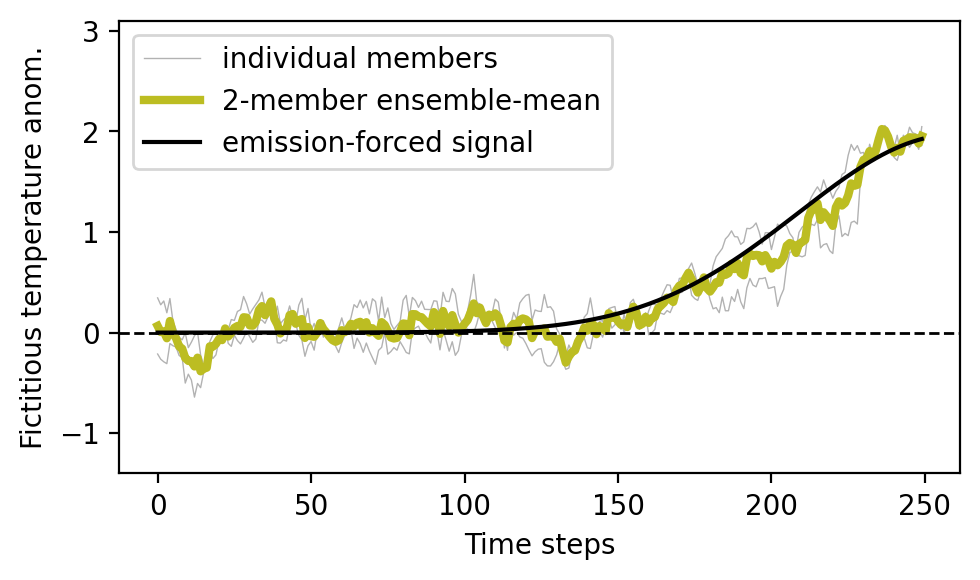

In [14]:
# Plot the result
ylim = (-1.4,3.1) # None
plt.figure(figsize=(5,3),dpi=200)
plt.plot(T_vec, ou_samples[0,...], color='black', label='individual members', alpha=0.3, linewidth=0.5,zorder=1)
plt.plot(T_vec, ou_samples[1:,...].transpose(), color='black', alpha=0.3, linewidth=0.5,zorder=1)
# plt.fill_between(T_vec, ou_samples.mean(axis=0) - ou_samples.std(axis=0), ou_samples.mean(axis=0) + ou_samples.std(axis=0), color='tab:olive', alpha=0.3) 
plt.plot(T_vec, ou_samples.mean(axis=0), color='tab:olive', label=f'{num_realizations_in_train}-member ensemble-mean', linewidth=3., zorder=2) 
plt.plot(T_vec, targets, color='black', label=f'emission-forced signal')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.ylim(ylim)
# plt.title("Local energy balance model samples")
plt.xlabel("Time steps")
plt.ylabel("Fictitious temperature anom.")
plt.tight_layout()
Path(filepath_to_save).mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + 'ou_samples.png')
plt.show()
plt.close()

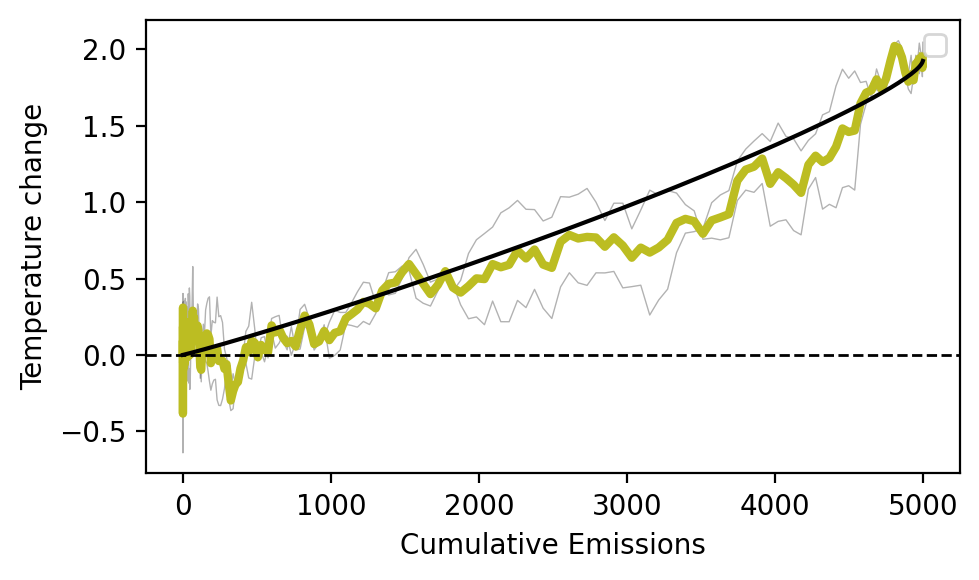

In [16]:
# Plot the result
plt.figure(figsize=(5,3),dpi=200)
plt.plot(cumul_emissions, ou_samples.transpose(), color='black', linewidth=0.5, alpha=0.3,zorder=1)
plt.plot(cumul_emissions, ou_samples.mean(axis=0), color='tab:olive', linewidth=3., zorder=2)
plt.plot(cumul_emissions, targets, color='black')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.legend()
# plt.ylim((-0.5,1.2))
plt.xlabel("Cumulative Emissions")
plt.ylabel("Temperature change")
plt.tight_layout()
Path(filepath_to_save).mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + 'ou_samples.png')
plt.show()
plt.close()

### Simulate a fictitious nonlinear climate variable as a function of temperature

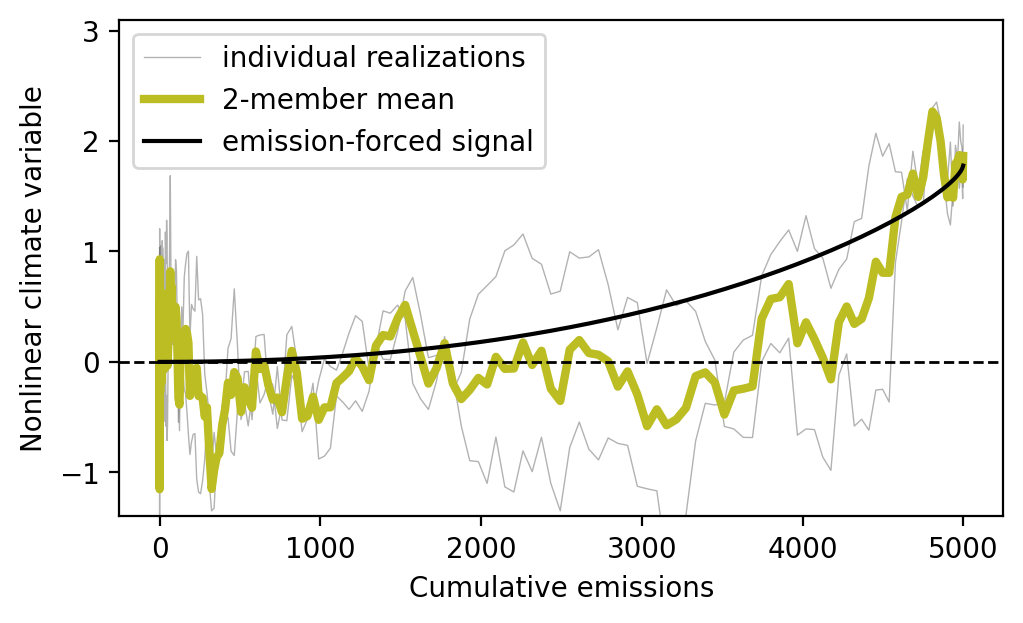

In [17]:
# Convert temperature into climate variable
# (JAMES25, Fig.7a)
def nonlinear_fn(x):
    #  Criteria: 
    #   50-member mean corresponds to signal reasonably well.
    #   climate variable over cumul emissions shows nonlinear curvature
    #   has stronger year-to-year fluctuations than temperature
    #   maps negative onto negative values
    return 0.03*(4.*x)**2
precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
precip_targets = nonlinear_fn(targets)

plt.figure(figsize=(5,3),dpi=200,layout='constrained')
plt.plot(cumul_emissions, precip_samples[0,...].transpose(), color='black', linewidth=0.5, alpha=0.3,zorder=1, label='individual realizations')
plt.plot(cumul_emissions, precip_samples[1:,...].transpose(), color='black', linewidth=0.5, alpha=0.3,zorder=1)
plt.plot(cumul_emissions, precip_samples.mean(axis=0), color='tab:olive', linewidth=3., zorder=2, label='2-member mean')
plt.plot(cumul_emissions, precip_targets, color='black', label='emission-forced signal')
plt.xlabel("Cumulative emissions")
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.legend(loc='upper left')
plt.ylim((-1.4,3.1))
plt.ylabel("Nonlinear climate variable")
Path(filepath_to_save).mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + '/titlefig/signal_over_emissions/nonlinear_climate_over_cumul_emissions.png')
plt.show()
plt.close()

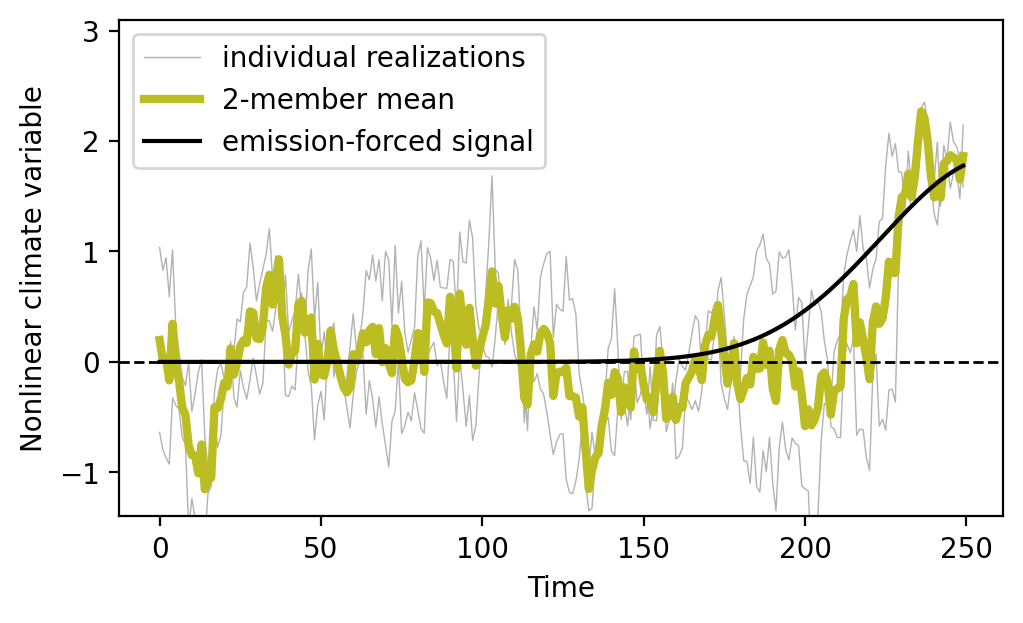

In [18]:
# JAMES25 Fig D1 d.
plt.figure(figsize=(5,3),dpi=200,layout='constrained')
plt.plot(T_vec, precip_samples[0,...].transpose(), color='black', linewidth=0.5, alpha=0.3,zorder=1, label='individual realizations')
plt.plot(T_vec, precip_samples[1:,...].transpose(), color='black', linewidth=0.5, alpha=0.3,zorder=1)
plt.plot(T_vec, precip_samples.mean(axis=0), color='tab:olive', linewidth=3., zorder=2, label='2-member mean')
plt.plot(T_vec, precip_targets, color='black', label='emission-forced signal')
plt.xlabel("Time")
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.ylim((-1.4,3.1))
plt.ylabel("Nonlinear climate variable")
Path(filepath_to_save).mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + '/titlefig/signal_over_emissions/nonlinear_climate_over_time.png')
plt.show()
plt.close()

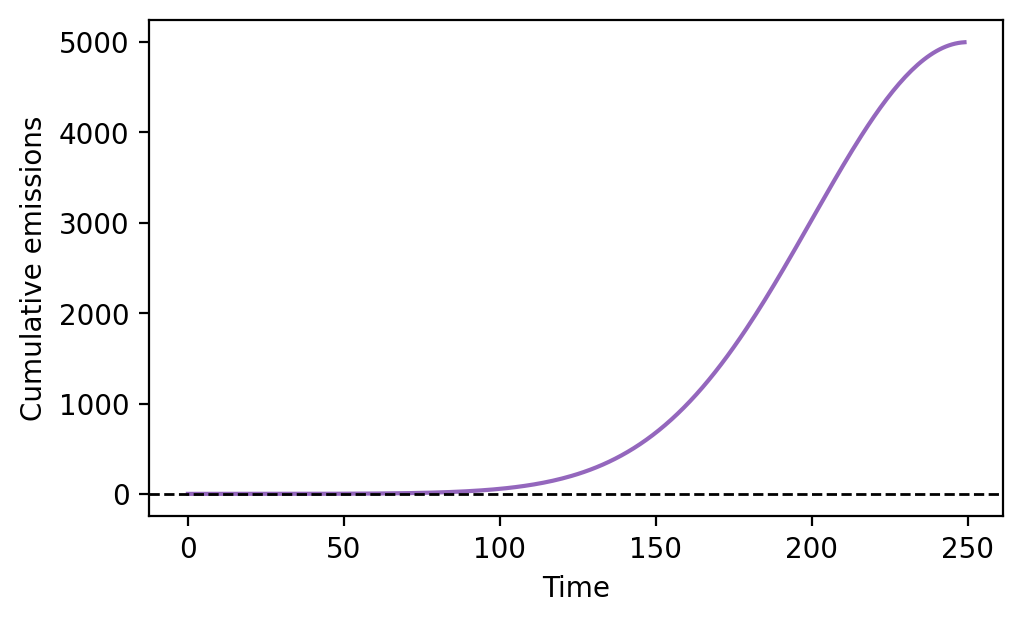

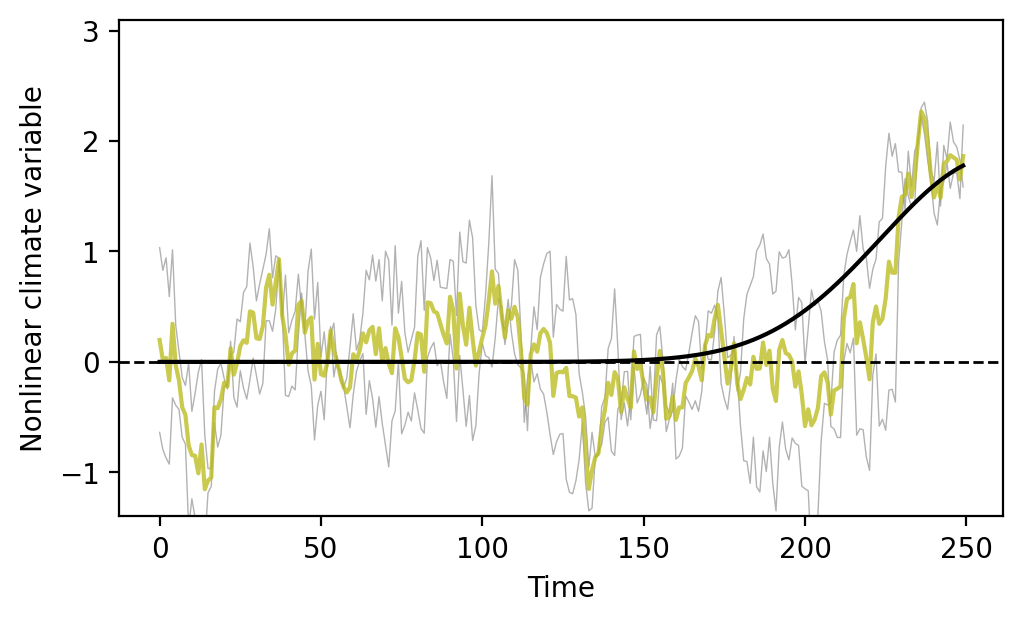

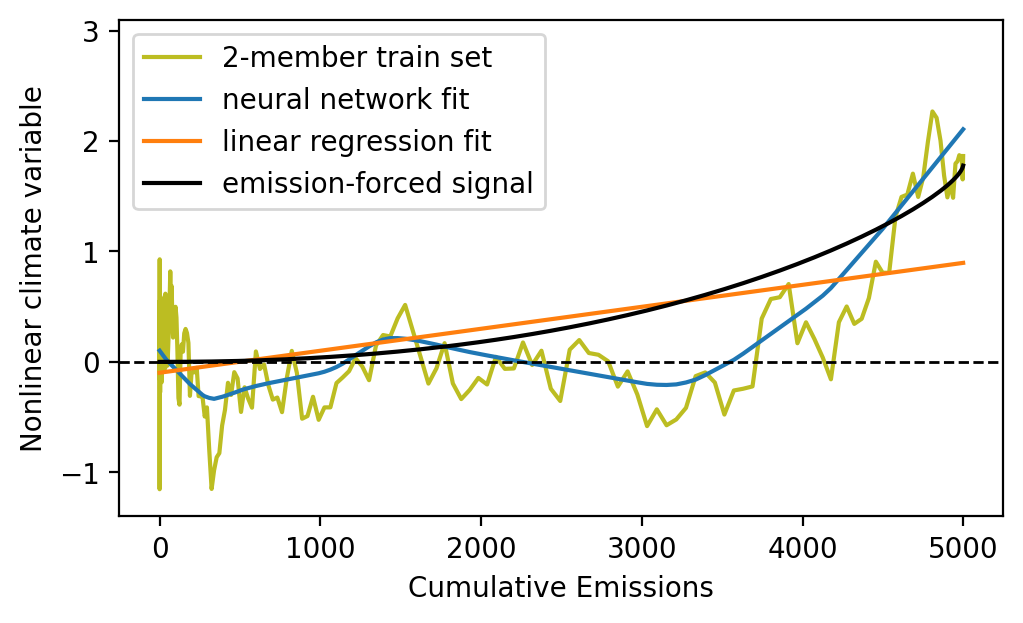

In [19]:
# Generate Fig D1a, D1d, and 7b
filepath_to_save_titlefig = f'{filepath_to_save}/titlefig/signal_over_emissions/' # relative filepath to save plots
seed = 53
add_axislabels = True
ylim=(-1.4,3.1)
dpi=200 # 50

## Cumulative emissions
plt.figure(figsize=(5,3),dpi=dpi,layout='constrained')
plt.plot(T_vec, cumul_emissions, color='tab:purple', label=f'emissions')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
# plt.ylim((-0.4,0.9))
if add_axislabels:
    plt.ylabel("Cumulative emissions")
    plt.xlabel("Time")
else:
    plt.gca().axes.yaxis.set_ticklabels([])
    plt.gca().axes.xaxis.set_ticklabels([])
Path(filepath_to_save_titlefig).mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save_titlefig + 'emissions.png', bbox_inches="tight")
plt.show()
plt.close()

## 2 - member
set_all_seeds(seed=seed)
num_realizations_in_train = 2
ou_samples, T_vec = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
    theta=theta,
    sigma=sigma)
precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
precip_targets = nonlinear_fn(targets)
Y_train = precip_samples

# Plot the result
plt.figure(figsize=(5,3),dpi=dpi,layout='constrained')
plt.plot(T_vec, Y_train[0,...], color='black', label='realizations from model with internal variability', alpha=0.3, linewidth=0.5)
plt.plot(T_vec, Y_train[1:,...].transpose(), color='black', alpha=0.3, linewidth=0.5)
plt.plot(T_vec, Y_train.mean(axis=0), color='tab:olive', label=f'ensemble mean', alpha=0.8)
plt.plot(T_vec, precip_targets, color='black', label=f'target emission-forced signal')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(ylim)
if add_axislabels:
    plt.ylabel("Nonlinear climate variable")
    plt.xlabel("Time")
else:
    plt.gca().axes.yaxis.set_ticklabels([])
    plt.gca().axes.xaxis.set_ticklabels([])
plt.savefig(filepath_to_save_titlefig + 'few_realizations.png', bbox_inches="tight")
plt.show()
plt.close()

import torch
from emcli2.utils.stochastic_process import train_time_series_model

## 2 - member fits
Y_val, T_vec = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
    theta=theta,
    sigma=sigma)
Y_val = nonlinear_fn(targets) + 3*(Y_val - targets)

Y_train = Y_train.mean(axis=0)[None,:]
X_train = torch.repeat_interleave(torch.from_numpy(cumul_emissions)[None,:], repeats=Y_train.shape[0], dim=0) / np.max(cumul_emissions)
Y_val = Y_val.mean(axis=0)[None,:]
X_val = X_train
X_test = torch.from_numpy(cumul_emissions)[None,:] / np.max(cumul_emissions)
trained_model, train_losses, val_losses, test_losses = train_time_series_model(X_train=X_train, Y_train=Y_train, 
                            X_val=X_val, Y_val=Y_val,
                            X_test=None, Y_test=None,
                            batch_size=500, 
                            epochs=150, 
                            learning_rate=0.005,
                            weight_decay=0.00001,
                            return_best_val_ckpt=True,
                            verbose=False)
X_train_linear = cumul_emissions / np.max(cumul_emissions)
coef = np.polyfit(X_train_linear,Y_train.mean(axis=0),1)
linear_preds = np.poly1d(coef)(X_train_linear)
fcn_preds = trained_model(X_test.squeeze()[:,None]).detach().numpy().squeeze()
plt.figure(figsize=(5,3),dpi=dpi,layout='constrained')
plt.plot(cumul_emissions, Y_train.mean(axis=0), label=f'{num_realizations_in_train}-member train set', color='tab:olive')
plt.plot(cumul_emissions, fcn_preds, label=r'neural network fit', color='tab:blue')
plt.plot(cumul_emissions, linear_preds, label=r'linear regression fit', color='tab:orange')
plt.plot(cumul_emissions, precip_targets, color='black', label=f'emission-forced signal',)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(ylim)
if add_axislabels:
    plt.xlabel("Cumulative Emissions")
    plt.ylabel("Nonlinear climate variable")
    plt.legend()
else:
    plt.gca().axes.yaxis.set_ticklabels([])
    plt.gca().axes.xaxis.set_ticklabels([])
plt.savefig(filepath_to_save_titlefig + f'few_realizations_fits.png', bbox_inches="tight")
plt.show()
plt.close()

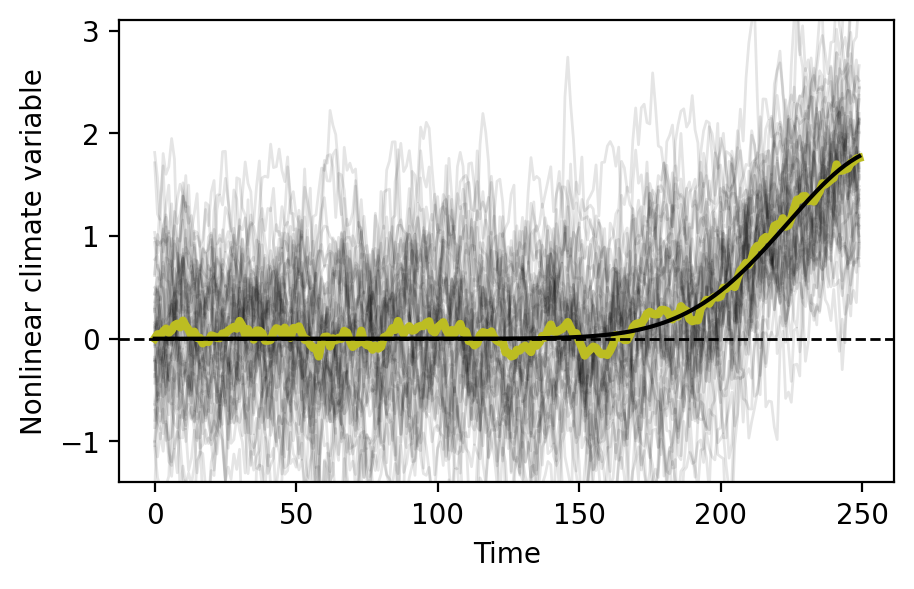

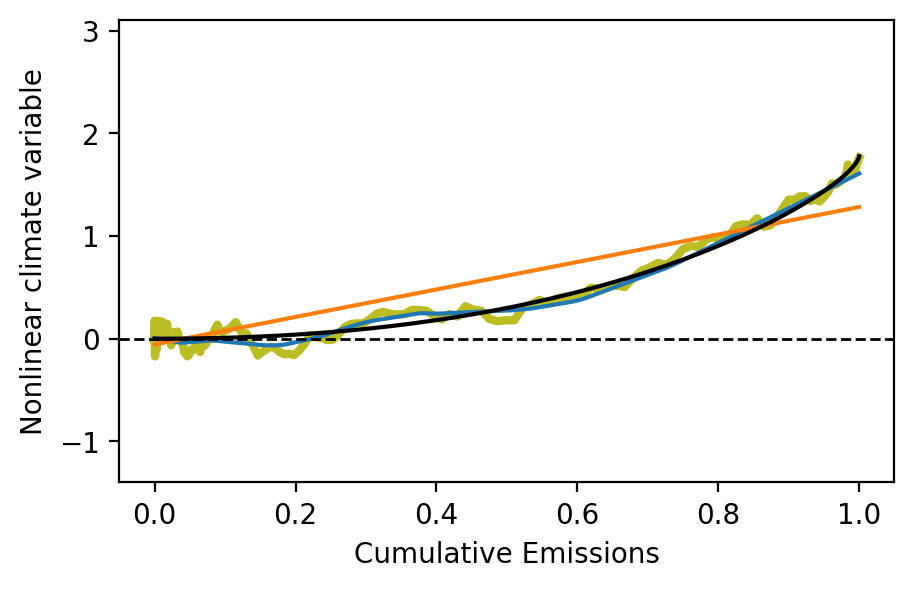

In [20]:
# Fit linear model to n-member mean

from tqdm.notebook import tqdm,trange

## 50 - member
set_all_seeds(seed=seed)
num_realizations_in_train = 50
ou_samples, T_vec = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
    theta=theta,
    sigma=sigma)
precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
Y_train = precip_samples

# Plot the result
plt.figure(figsize=(5,3),dpi=dpi)
plt.plot(T_vec, Y_train[0,...], color='black', label='individual members', alpha=0.1, linewidth=1.0, zorder=1)
plt.plot(T_vec, Y_train[1:,...].transpose(), color='black', alpha=0.1, linewidth=1.0, zorder=1)
plt.plot(T_vec, Y_train.mean(axis=0), color='tab:olive', linewidth=3., zorder=2)
plt.plot(T_vec, precip_targets, color='black', label=f'target w/o noise')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(ylim)
if add_axislabels:
    plt.xlabel("Time")
    plt.ylabel("Nonlinear climate variable")
else:
    plt.gca().axes.yaxis.set_ticklabels([])
    plt.gca().axes.xaxis.set_ticklabels([])
# plt.tight_layout()
plt.savefig(filepath_to_save_titlefig + 'many_realizations.png', bbox_inches="tight")
plt.show()
plt.close()

num_draws = 1 # for presentation: 20
num_realizations_in_train = 50
set_all_seeds(seed=seed) # 48, 67; 44 for paper

# Plots
plt.figure(figsize=(5,3),dpi=dpi)
for i in range(num_draws):
    label_trainset = f'{num_realizations_in_train}-member train sets' if i == 0 else None        
    label_linearfit = f'neural net per train set' if i == 0 else None
    ou_samples, T_vec = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
    Y_train = precip_samples

    Y_val, T_vec = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    Y_val = nonlinear_fn(targets) + 3*(Y_val - targets)
    Y_val = Y_val.mean(axis=0)[None,:]
    X_val = X_train

    X_test = torch.from_numpy(cumul_emissions)[None,:] / np.max(cumul_emissions)

    # Preprocess datasets
    Y_train = Y_train.mean(axis=0)[None,:]
    x_vals = cumul_emissions / np.max(cumul_emissions)
    X_train = torch.repeat_interleave(torch.from_numpy(x_vals)[None,:], repeats=Y_train.shape[0], dim=0)

    coef = np.polyfit(x_vals,Y_train.mean(axis=0),1)
    linear_preds = np.poly1d(coef)(x_vals)

    # Fit neural net
    trained_model, train_losses, val_losses, test_losses = train_time_series_model(X_train=X_train, Y_train=Y_train,
                                X_val=X_val, Y_val=Y_val,
                                batch_size=500, 
                                epochs=150, 
                                learning_rate=0.005,
                                weight_decay=0.00001,
                                return_best_val_ckpt=True, 
                                verbose=False)
    fcn_preds = trained_model(X_test.squeeze()[:,None]).detach().numpy().squeeze()

    if i<=0:
        plt.plot(x_vals, Y_train.mean(axis=0), label=label_trainset, color='tab:olive', zorder=1, linewidth=3.) # alpha=0.6, linewidth=0.5,
        plt.plot(x_vals, fcn_preds, label=label_linearfit, color='tab:blue', linewidth=1.5)
        plt.plot(x_vals, linear_preds, label=label_linearfit, color='tab:orange', linewidth=1.5)

plt.plot(x_vals, precip_targets, label=r'target w/o noise', color='black')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylim(ylim)
if add_axislabels:
    plt.xlabel('Cumulative Emissions')
    plt.ylabel('Nonlinear climate variable')
else:
    plt.gca().axes.yaxis.set_ticklabels([])
    plt.gca().xaxis.set_major_formatter(plt.NullFormatter())

plt.savefig(filepath_to_save_titlefig + f'many_realizations_fits.png', bbox_inches="tight")
plt.show()
plt.close()

## Plot RMSE over #realizations-in-train-set

In [24]:
import shutil
from emcli2.utils.stochastic_process import run_stochastic_process_experiment
from emcli2.utils.stochastic_process import run_stochastic_process_experiment_spatial_MSE

num_train_samples_set = np.array([1,2,4,7,10,30]) # np.array([1,2,10]) #
num_draws = 10 # number of draws to estimate the population statistics
# For the JAMES25 results, set num_draws to 2000 
#  and num_train_samples_set to np.array([1,2,3,4,5,6,7,8,9,10,12,15,20,25,30,40,50])

dir_temp = f'../docs/figures/{process_name}/temp/'
if os.path.exists(dir_temp):
    # Remove directory to make sure plotting works
    shutil.rmtree(dir_temp) 

# (This may take 1-2minutes. Decrease num_draws for faster runtimes)
run_stochastic_process_experiment_spatial_MSE(targets=np.zeros(time_steps),
                                  num_train_samples_set=num_train_samples_set, 
                                  num_draws=num_draws, 
                                  process_name=process_name,
                                  dir_figures=dir_temp,
                                  dir_ckpts=None, 
                                  use_best_val_ckpt=True,
                                  nonlinearity='quadratic')

100%|██████████| 10/10 [00:13<00:00,  1.39s/it]
6it [01:25, 14.30s/it]


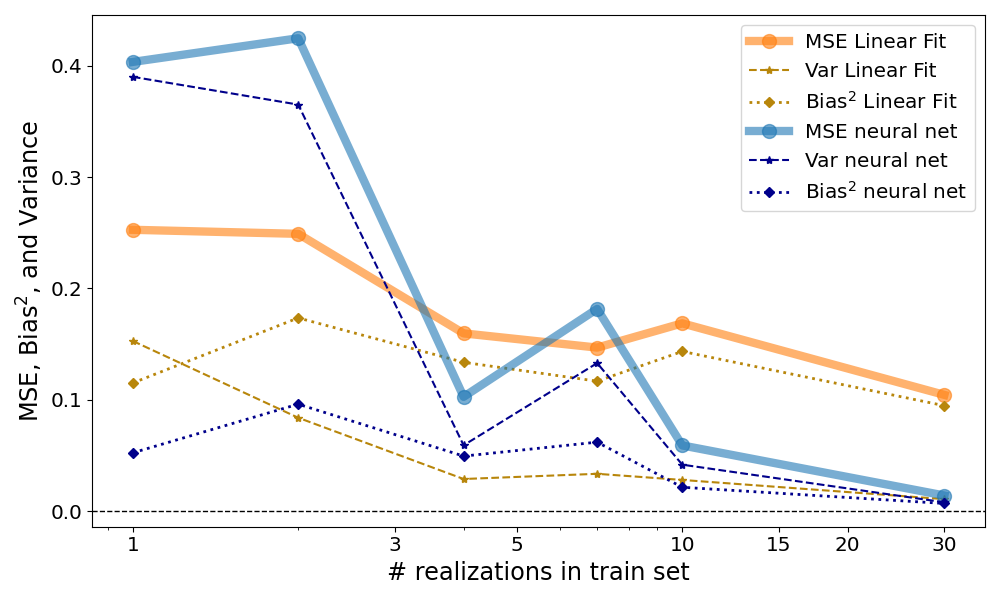

In [25]:
# JAMES2 Fig 7f
from IPython.display import Image
Image(dir_temp + '/spatial_MSE/bias_var_log.png')

## Illustrate the variance and bias by plotting predictions against targets

  0%|          | 0/100 [00:00<?, ?it/s]

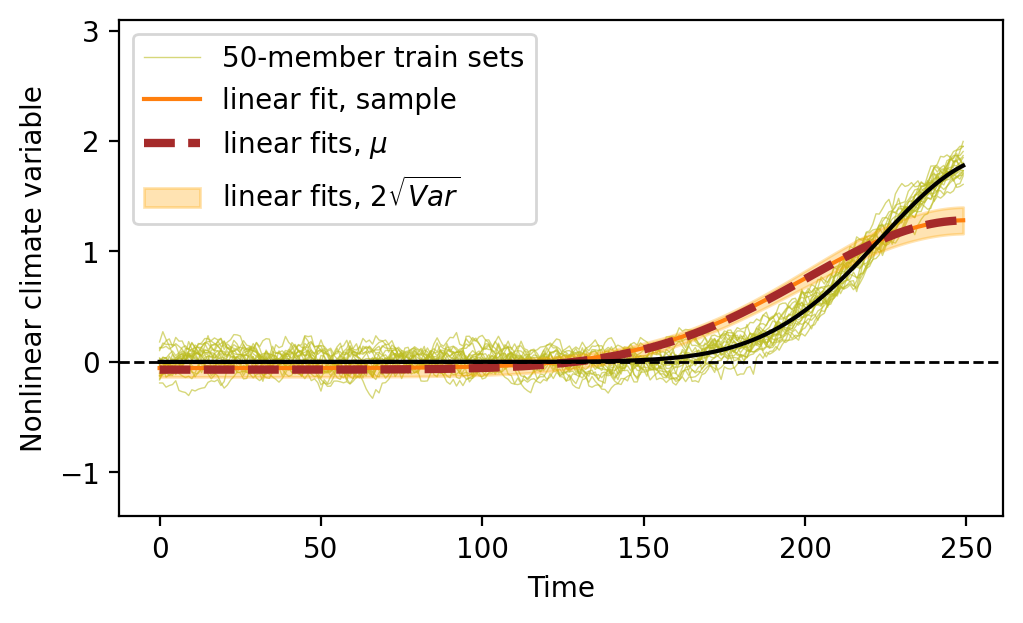

In [29]:
# Fig D1c, linear model, 50members

from emcli2.utils.stochastic_process import generate_ornstein_uhlenbeck_process

# Define the target function
plt_for_pptx = False # set to False for plot in paper; True for plot in presentation
num_draws = 100
num_realizations_in_train = 50
set_all_seeds(seed=53) #44
xaxis = 'time' # 'time'
if xaxis == 'cumul_emissions':
    x_vals = cumul_emissions
    xlabel = 'Cumulative emissions'
else:
    x_vals = T_vec
    xlabel = 'Time'

linear_preds_all = np.zeros((num_draws, time_steps), dtype=np.float32)
# Plots
plt.figure(figsize=(5,3),dpi=200,layout='constrained')
for i in trange(num_draws):
    label_trainset = f'{num_realizations_in_train}-member train sets' if i == 0 else None        
    label_linearfit = f'linear fit, sample' if i == 0 else None

    ou_samples, T_vec = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
    Y_train = precip_samples
    Y_train_mean = Y_train.mean(axis=0)

    X_train_linear = cumul_emissions / np.max(cumul_emissions)
    coef = np.polyfit(X_train_linear,Y_train.mean(axis=0),1)
    linear_preds = np.poly1d(coef)(X_train_linear)
    linear_preds_all[i,:] = linear_preds

    if not plt_for_pptx:
        if i <= 20:
            plt.plot(x_vals, Y_train.mean(axis=0), label=label_trainset, alpha=0.6, linewidth=0.5, color='tab:olive', zorder=1)
        if i <= 0:
            plt.plot(x_vals, linear_preds, label=label_linearfit, color='tab:orange')
    elif i <= 0:
        plt.plot(x_vals, Y_train.mean(axis=0), label=label_trainset, color='tab:olive', zorder=1) 
        plt.plot(x_vals, linear_preds, label=label_linearfit, color='tab:orange') # sample linear fit

if not plt_for_pptx:
    linear_preds_mean = linear_preds_all.mean(axis=0)
    linear_preds_std = 2*linear_preds_all.std(axis=0)
    plt.plot(x_vals, linear_preds_mean, color='brown', linestyle='--', linewidth=3, label=r'linear fits, $\mu$')
    plt.fill_between(x_vals, linear_preds_mean-linear_preds_std, linear_preds_mean+linear_preds_std, alpha=0.3, color='orange', label=r'linear fits, $2\sqrt{Var}$')
plt.plot(x_vals, precip_targets, color='black') # label=r'emission-forced signal',
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel(xlabel)
plt.ylabel('Nonlinear climate variable')
plt.ylim(ylim)
plt.legend(loc='upper left')
Path(filepath_to_save + '/preds/').mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + f'/preds/linear_fits_{xaxis}_{num_realizations_in_train}members.png')
plt.show()
plt.close()

  0%|          | 0/100 [00:00<?, ?it/s]

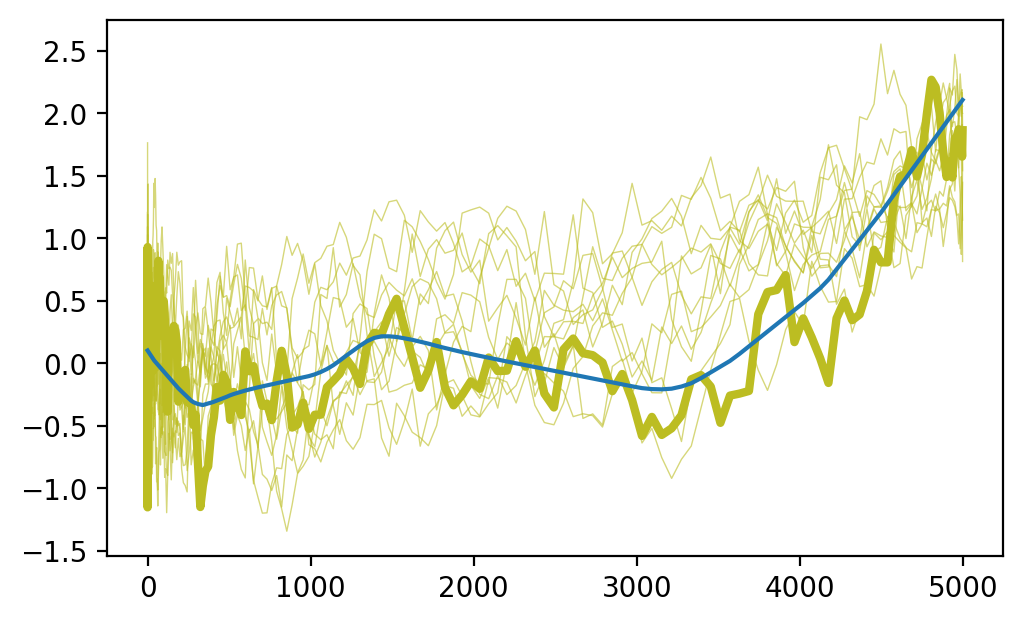

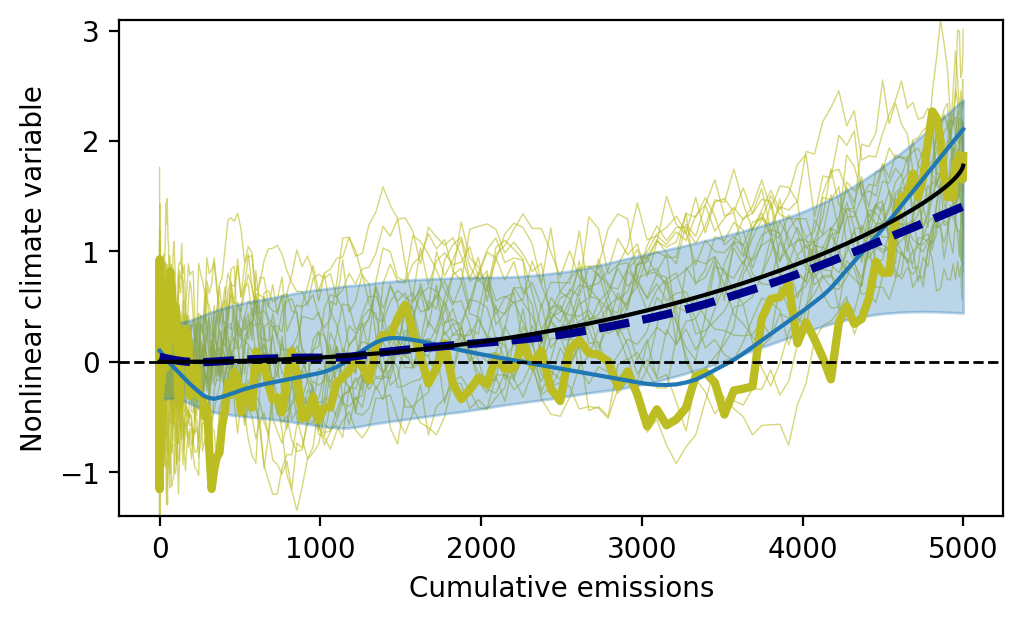

In [ ]:
#Fig 7e, neural net, 2-member

from emcli2.utils.stochastic_process import generate_ornstein_uhlenbeck_process

# Define the target function
plt_for_pptx = False # set to False for plot in paper; True for plot in presentation
num_draws = 100
num_realizations_in_train = 2 # 50
set_all_seeds(seed=53) #44
xaxis = 'cumul_emissions' # 'time'
if xaxis == 'cumul_emissions':
    x_vals = cumul_emissions
    xlabel = 'Cumulative emissions'
else:
    x_vals = T_vec
    xlabel = 'Time'

fcn_preds_all = np.zeros((num_draws, time_steps), dtype=np.float32)
# Plots
plt.figure(figsize=(5,3),dpi=200,layout='constrained')
for i in trange(num_draws):
    label_trainset = f'{num_realizations_in_train}-member train sets' if i == 0 else None        
    label_linearfit = f'neural net fit, sample' if i == 0 else None

    ou_samples, T_vec = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
    Y_train = precip_samples
    Y_train_mean = Y_train.mean(axis=0)

    Y_val, T_vec = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    Y_val = nonlinear_fn(targets) + 3*(Y_val - targets)
    Y_val = Y_val.mean(axis=0)[None,:]
    X_val = X_train
    X_test = torch.from_numpy(cumul_emissions)[None,:] / np.max(cumul_emissions)

    # Compute spectrum of neural net predictions
    Y_train = Y_train.mean(axis=0)[None,:]
    trained_model, train_losses, val_losses, test_losses = train_time_series_model(X_train=X_train, Y_train=Y_train,
                                X_val=X_val, Y_val=Y_val,
                                batch_size=500, 
                                epochs=150, 
                                learning_rate=0.005,
                                weight_decay=0.00001,
                                return_best_val_ckpt=True, 
                                verbose=False)
    fcn_preds = trained_model(X_test.squeeze()[:,None]).detach().numpy().squeeze()
    fcn_preds_all[i,:] = fcn_preds

    if not plt_for_pptx:
        if i <= 20:
            plt.plot(x_vals, Y_train.mean(axis=0), label=label_trainset, alpha=0.6, linewidth=0.5, color='tab:olive', zorder=1)
        if i <= 0:
            plt.plot(x_vals, Y_train.mean(axis=0), color='tab:olive', linewidth=3., zorder=2)
            plt.plot(x_vals, fcn_preds, label=label_linearfit, color='tab:blue')
    elif i <= 0:
        plt.plot(x_vals, Y_train.mean(axis=0), label=label_trainset, color='tab:olive', zorder=1) 
        plt.plot(x_vals, fcn_preds, label=label_linearfit, color='tab:blue') # sample fit

if not plt_for_pptx:
    fcn_preds_mean = fcn_preds_all.mean(axis=0)
    fcn_preds_std = 2*fcn_preds_all.std(axis=0)
    plt.plot(x_vals, fcn_preds_mean, color='darkblue', linestyle='--', linewidth=3, label=r'neural net fits, $\mu$')
    plt.fill_between(x_vals, fcn_preds_mean-fcn_preds_std, fcn_preds_mean+fcn_preds_std, alpha=0.3, color='tab:blue', label=r'neural net fits, $2\sqrt{Var}$')
plt.plot(x_vals, precip_targets, color='black') #  label=r'target w/o noise',
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel(xlabel)
plt.ylabel('Nonlinear climate variable')
plt.ylim(ylim)
# plt.legend()
Path(filepath_to_save + '/preds/').mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + f'/preds/fcn_fits_{num_realizations_in_train}members.png')
plt.show()
plt.close()

In [32]:
filepath_to_save

'../docs/figures/energy_balance_nonlinear_quadratic/'

### Plot function spectra

In [ ]:
# Fig 7c

num_train_samples_set = np.array([2, 50])# ,3,4,5,10,50,100,200]) 
num_draws = 500 # number of draws to estimate the population statistics
num_frequencies = int(time_steps/2 + 1)
amplitudes_targets = np.zeros((len(num_train_samples_set), num_frequencies))
amplitudes_linear_preds = np.zeros((len(num_train_samples_set), num_frequencies))
amplitudes_fcn_preds = np.zeros((len(num_train_samples_set), num_frequencies))

for r, num_realizations_in_train in enumerate(num_train_samples_set):
    for _ in tqdm(range(num_draws)):
        ou_samples, T_vec = generate_energy_balance_model(
            time_steps=time_steps,
            num_samples=num_realizations_in_train,
            forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
            theta=theta,
            sigma=sigma)
        precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
        Y_train = precip_samples
        Y_train_mean = Y_train.mean(axis=0)

        Y_val, T_vec = generate_energy_balance_model(
            time_steps=time_steps,
            num_samples=num_realizations_in_train,
            forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
            theta=theta,
            sigma=sigma)
        Y_val = nonlinear_fn(targets) + 3*(Y_val - targets)
        Y_val = Y_val.mean(axis=0)[None,:]
        X_val = X_train

        X_test = torch.from_numpy(cumul_emissions)[None,:] / np.max(cumul_emissions)

        # Compute the FFT and amplitudes of the trend-removed noisy targets
        fft_targets = np.fft.rfft(Y_train_mean - precip_targets)
        amplitudes_targets[r,:] += np.abs(fft_targets)**2

        # Compute spectrum of the linear fit
        coef = np.polyfit(x_vals,Y_train.mean(axis=0),1)
        coef[0] = 0. # Set intercept of linear fit to zero
        linear_preds = np.poly1d(coef)(x_vals)
        fft_linear_preds = np.fft.rfft(linear_preds)
        amplitudes_linear_preds[r,:] += np.abs(fft_linear_preds)**2

        # Compute spectrum of neural net predictions
        Y_train = Y_train.mean(axis=0)[None,:]
        trained_model, train_losses, val_losses, test_losses = train_time_series_model(X_train=X_train, Y_train=Y_train,
                                    X_val=X_val, Y_val=Y_val,
                                    batch_size=500, 
                                    epochs=150, 
                                    learning_rate=0.005,
                                    weight_decay=0.00001,
                                    return_best_val_ckpt=True, 
                                    verbose=False)
        fcn_preds = trained_model(X_test.squeeze()[:,None]).detach().numpy().squeeze()
        fft_fcn_preds = np.fft.rfft(fcn_preds - precip_targets)
        amplitudes_fcn_preds[r,:] += np.abs(fft_fcn_preds)**2

    # Compute the average amplitudes_targets
    amplitudes_targets[r,:] = amplitudes_targets[r,:] / float(num_draws)
    amplitudes_linear_preds[r,:] = amplitudes_linear_preds[r,:] / float(num_draws)
    amplitudes_fcn_preds[r,:] = amplitudes_fcn_preds[r,:] / float(num_draws)

# Compute the frequency axis
freq = np.fft.rfftfreq(time_steps)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

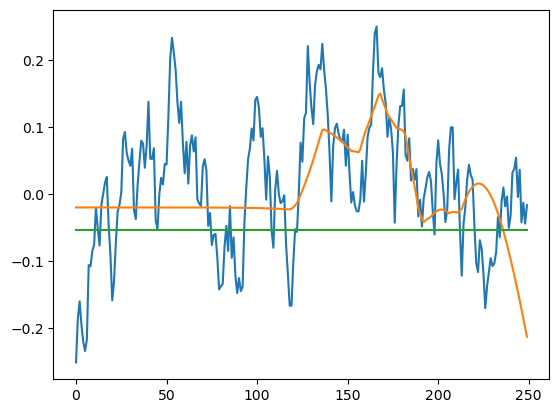

In [ ]:
plt.plot(T_vec, Y_train_mean - precip_targets)
plt.plot(T_vec, fcn_preds - precip_targets)
plt.plot(T_vec, linear_preds)
plt.show()

/tmp/ipykernel_4045305/374609354.py:8: RuntimeWarning: divide by zero encountered in reciprocal
  plt.plot(freq**-1, amplitudes_targets[r,:], color='tab:olive', linestyle='--', alpha=0.7, label=f'{num_realizations_in_train}-member train sets')
/tmp/ipykernel_4045305/374609354.py:9: RuntimeWarning: divide by zero encountered in reciprocal
  plt.plot(freq**-1, amplitudes_fcn_preds[r,:], color='tab:blue', linestyle='--', alpha=0.7, label=f'{num_realizations_in_train}-member neural net bias')
/tmp/ipykernel_4045305/374609354.py:18: RuntimeWarning: divide by zero encountered in reciprocal
  plt.plot(freq**-1, amplitudes_targets[r,:], color='tab:olive', alpha=0.7, label=f'{num_realizations_in_train}-member train sets')
/tmp/ipykernel_4045305/374609354.py:19: RuntimeWarning: divide by zero encountered in reciprocal
  plt.plot(freq**-1, amplitudes_fcn_preds[r,:], color='tab:blue', alpha=0.7, label=f'{num_realizations_in_train}-member neural net bias')
/tmp/ipykernel_4045305/374609354.py:20: Ru

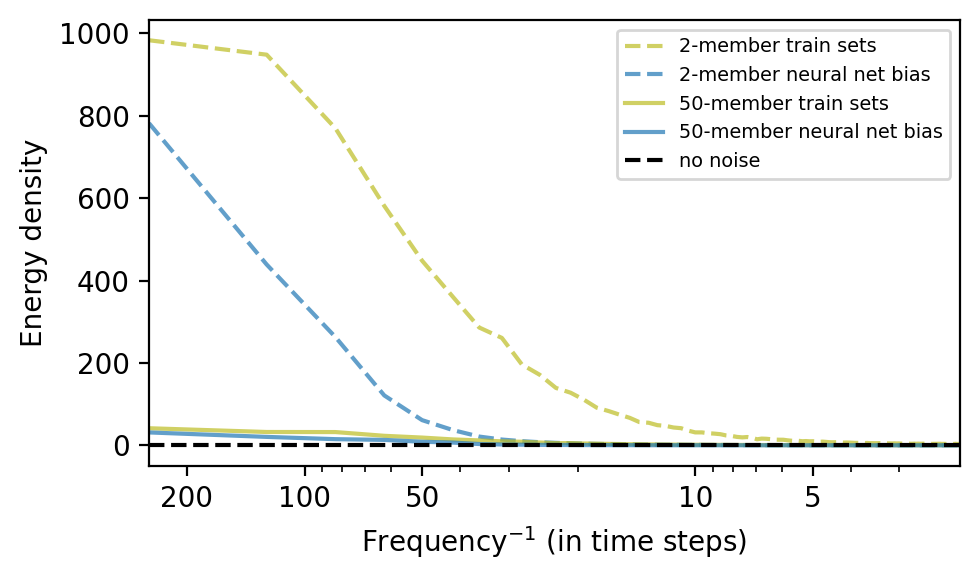

In [ ]:
import matplotlib 
filepath_to_save = '../docs/figures/energy_balance_nonlinear_quadratic/' # relative filepath to save plots
fft_targets_wo_noise = np.fft.rfft(targets)
amplitudes_targets_wo_noise = np.abs(fft_targets_wo_noise)**2

plt.figure(figsize=(5,3),dpi=200,layout='constrained')
for r, num_realizations_in_train in enumerate(num_train_samples_set):
    plt.plot(freq**-1, amplitudes_targets[r,:], color='tab:olive', linestyle='--', alpha=0.7, label=f'{num_realizations_in_train}-member train sets')
    plt.plot(freq**-1, amplitudes_fcn_preds[r,:], color='tab:blue', linestyle='--', alpha=0.7, label=f'{num_realizations_in_train}-member neural net bias')
    # plt.plot(freq**-1, amplitudes_linear_preds[r,:], color='tab:orange', linestyle='--', alpha=0.7, label=f'linear fit')
    # plt.plot(freq**-1, amplitudes_targets_wo_noise, color='black', linestyle='solid', alpha=0.7, zorder=1, label=f'target w/o noise')
    break
if len(num_train_samples_set) > 1:
    # Plot spectrum for different number of members
    for r, num_realizations_in_train in enumerate(num_train_samples_set):
        if r == 0:
            continue
        plt.plot(freq**-1, amplitudes_targets[r,:], color='tab:olive', alpha=0.7, label=f'{num_realizations_in_train}-member train sets')
        plt.plot(freq**-1, amplitudes_fcn_preds[r,:], color='tab:blue', alpha=0.7, label=f'{num_realizations_in_train}-member neural net bias')
        plt.plot(freq**-1, np.zeros(len(freq)), color='black', linestyle='--', alpha=1., label=f'no noise')
        # plt.plot(freq**-1, amplitudes_linear_preds[r,:], color='tab:orange', alpha=0.7, label=f'{num_realizations_in_train}-m linear fit')
# plt.yscale('log')
plt.xscale('log')
plt.xlim((freq[1]**-1,(freq[-1]**-1)+0.1))
plt.gca().set_xticks([200,100,50,10,5])
plt.gca().xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
# plt.ylim((1e-3,1e4))
# plt.title('Fourier Spectra of train set, neural net, and linear')
# plt.title('Fourier Spectra with linear component removed')
plt.xlabel(r'Frequency$^{-1}$ (in time steps)')
plt.ylabel('Energy density')
plt.legend(fontsize='x-small')
Path(filepath_to_save + 'fourier/').mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + f'fourier/{num_realizations_in_train}-member.png')
plt.show()
plt.close()

MSE, Bias^2, and Variance

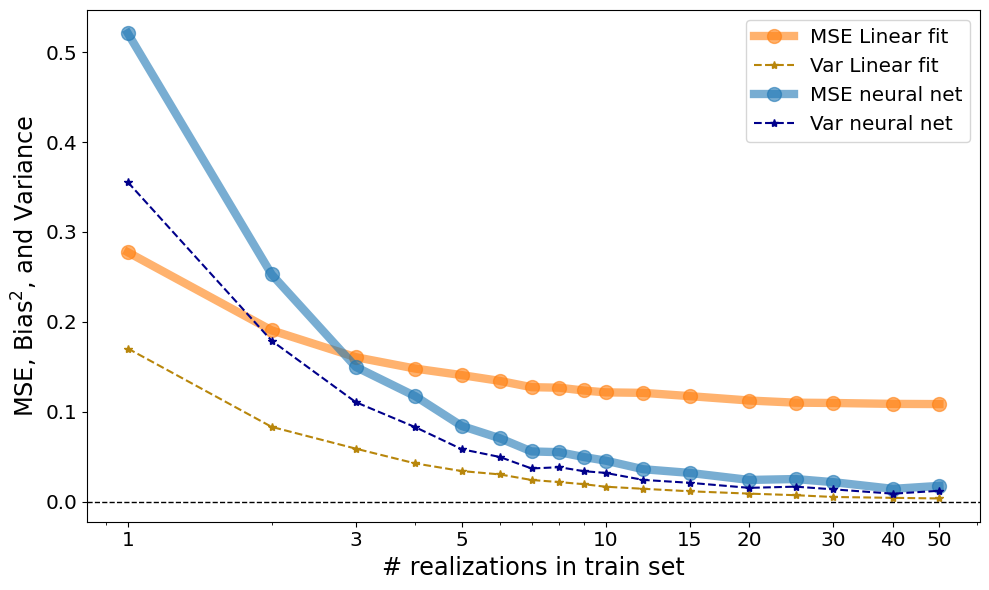

In [16]:
num_train_samples_set = np.array([1,2,3,4,5,6,7,8,9,10,12,15,20,25,30,40,50])
mse_fcn = np.load('../runs/energy_balance_nonlinear_quadratic/2000draws/tmp_mse_fcn.npy')
var_fcn = np.load('../runs/energy_balance_nonlinear_quadratic/2000draws/tmp_var_fcn.npy')
mse_simple = np.load('../runs/energy_balance_nonlinear_quadratic/2000draws/tmp_mse_linear.npy')
var_simple = np.load('../runs/energy_balance_nonlinear_quadratic/2000draws/tmp_var_linear.npy')
filepath_to_save = f'../docs/figures/{process_name}/2000draws/spatial_MSE/bias_var_log_1'

plt.figure(figsize=(10, 6))
params = {'legend.fontsize': 'x-large',
        'axes.labelsize': 'xx-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

label_simple_model = 'Linear fit'
plt.plot(num_train_samples_set, mse_simple.mean(axis=1), label=f'MSE {label_simple_model}', color='tab:orange', linestyle='-', linewidth='6', marker='o', markersize=10,alpha=0.6)
#plt.fill_between(num_train_samples_set, mse_simple.mean(axis=1)+mse_simple.std(axis=1), mse_simple.mean(axis=1)-mse_simple.std(axis=1), color='tab:orange', alpha=0.2)
plt.plot(num_train_samples_set, var_simple, label=f'Var {label_simple_model}', color='darkgoldenrod', linestyle='--', marker='*')#, alpha=0.)
#plt.plot(num_train_samples_set, sbias_simple, label=rf'Bias$^2$ {label_simple_model}', color='darkgoldenrod', linestyle='dotted', marker='D',markersize=5,linewidth=2)

plt.plot(num_train_samples_set, mse_fcn.mean(axis=1), label='MSE neural net', color='tab:blue', linestyle='-', linewidth='6', marker='o', markersize=10,alpha=0.6)
#plt.fill_between(num_train_samples_set, mse_fcn.mean(axis=1)+mse_fcn.std(axis=1), mse_fcn.mean(axis=1)-mse_fcn.std(axis=1), color='tab:blue', alpha=0.2)
plt.plot(num_train_samples_set, var_fcn, label='Var neural net', color='darkblue', linestyle='--', marker='*')#, alpha=0.)
#plt.plot(num_train_samples_set, sbias_fcn, label=r'Bias$^2$ neural net', color='darkblue', linestyle='dotted', marker='D',markersize=5,linewidth=2)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
from matplotlib.ticker import ScalarFormatter
plt.xscale('log')
xticks = [1,3,5,10,15,20,30,40,50,100]
# Remove values that are too high
iter=0
for _ in np.arange(len(xticks)):
    if xticks[iter] > num_train_samples_set.max():
        xticks.remove(xticks[iter])
    else:
        iter += 1
plt.xticks(xticks)
plt.gca().get_xaxis().set_major_formatter(ScalarFormatter())
plt.xlabel('# realizations in train set')
plt.ylabel(r'MSE, Bias$^2$, and Variance')
plt.legend()            
plt.tight_layout()
Path(filepath_to_save + '.png').parent.mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save)
plt.show()
plt.close()
plt.rcParams.clear()
plt.rcParams.update(plt.rcParamsDefault)

## Generate presentation figure

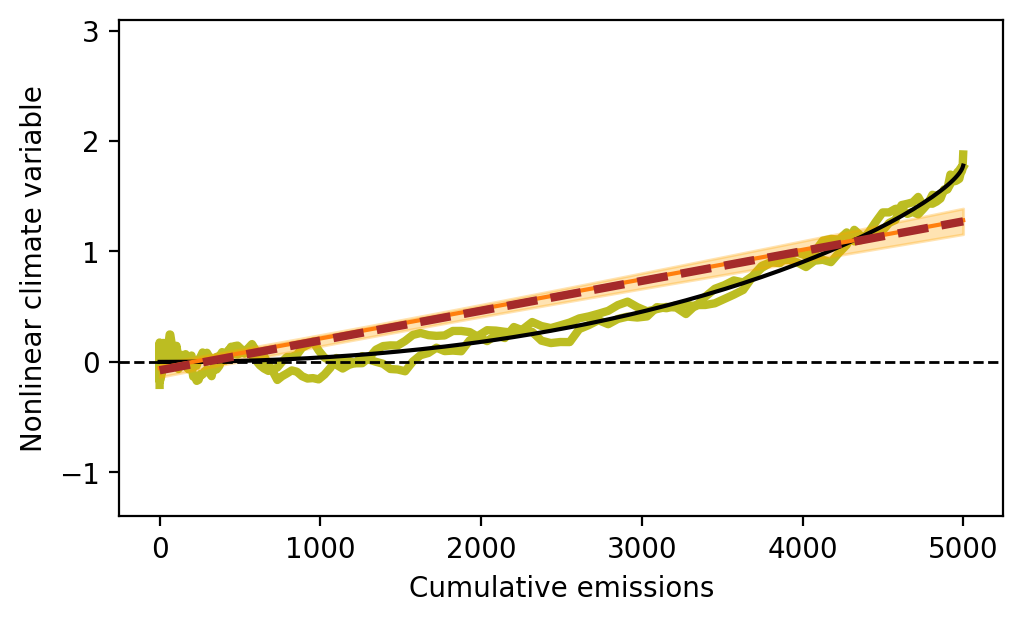

In [ ]:
import torch
from emcli2.utils.stochastic_process import train_time_series_model

num_realizations_in_train = 50
set_all_seeds(seed=seed)
# 2 realizations + ensemble-mean
ou_samples, T_vec = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=forcing,
    theta=theta,
    sigma=sigma)
precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)

## 2-member neural net and linear fit
Y_val, _ = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=forcing,
    theta=theta,
    sigma=sigma)
Y_val = nonlinear_fn(targets) + 3*(Y_val - targets)
Y_train = precip_samples
Y_train = Y_train.mean(axis=0)[None,:]
X_train = torch.repeat_interleave(torch.from_numpy(cumul_emissions)[None,:], repeats=Y_train.shape[0], dim=0) / np.max(cumul_emissions)
Y_val = Y_val.mean(axis=0)[None,:]
X_val = X_train
X_test = torch.from_numpy(cumul_emissions)[None,:] / np.max(cumul_emissions)
trained_model, train_losses, val_losses, test_losses = train_time_series_model(X_train=X_train, Y_train=Y_train, 
                            X_val=X_val, Y_val=Y_val,
                            X_test=None, Y_test=None,
                            batch_size=500, 
                            epochs=150, 
                            learning_rate=0.005,
                            weight_decay=0.00001,
                            return_best_val_ckpt=True,
                            verbose=False)
fcn_preds = trained_model(X_test.squeeze()[:,None]).detach().numpy().squeeze()

X_train_linear = cumul_emissions / np.max(cumul_emissions)
coef = np.polyfit(X_train_linear,Y_train.mean(axis=0),1)
linear_preds = np.poly1d(coef)(X_train_linear)

# 2nd training set
set_all_seeds(seed=41)
ou_samples2, _ = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=forcing,
    theta=theta,
    sigma=sigma)
precip_samples2 = nonlinear_fn(targets) + 3*(ou_samples2 - targets)

Y_val2, _ = generate_energy_balance_model(
    time_steps=time_steps,
    num_samples=num_realizations_in_train,
    forcing=forcing,
    theta=theta,
    sigma=sigma)
Y_val2 = nonlinear_fn(targets) + 3*(Y_val2 - targets)
Y_val2 = Y_val2.mean(axis=0)[None,:]
Y_train2 = precip_samples2
trained_model2, _, _, _ = train_time_series_model(X_train=X_train, Y_train=Y_train2, 
                            X_val=X_val, Y_val=Y_val2,
                            X_test=None, Y_test=None,
                            batch_size=500, 
                            epochs=150, 
                            learning_rate=0.005,
                            weight_decay=0.00001,
                            return_best_val_ckpt=True,
                            verbose=False)
fcn_preds2 = trained_model2(X_test.squeeze()[:,None]).detach().numpy().squeeze()

coef2 = np.polyfit(X_train_linear,Y_train2.mean(axis=0),1)
linear_preds2 = np.poly1d(coef2)(X_train_linear)

plt.figure(figsize=(5,3),dpi=200,layout='constrained')
#plt.plot(cumul_emissions, precip_samples[0,...].transpose(), color='black', linewidth=0.5, alpha=0.3,zorder=1, label='individual realizations')
#plt.plot(cumul_emissions, precip_samples[1:,...].transpose(), color='black', linewidth=0.5, alpha=0.3,zorder=1)
plt.plot(cumul_emissions, precip_samples.mean(axis=0), color='tab:olive', linewidth=3., zorder=2, label='2-member mean')
plt.plot(cumul_emissions, precip_samples2.mean(axis=0), color='tab:olive', linewidth=3., zorder=2, label='2-member mean')
#plt.plot(cumul_emissions, fcn_preds, label=r'neural network fit', color='tab:blue', zorder=3)
#plt.plot(cumul_emissions, fcn_preds2, label=r'neural network fit', color='tab:blue', zorder=3)
#plt.plot(cumul_emissions, fcn_preds_mean, color='darkblue', linestyle='--', linewidth=3, label=r'neural net fits, $\mu$', zorder=4)
#plt.fill_between(cumul_emissions, fcn_preds_mean+fcn_preds_std, fcn_preds_mean-fcn_preds_std,  alpha=0.3, color='tab:blue', label=r'neural net fits, $2\sqrt{Var}$', zorder=2)
plt.plot(cumul_emissions, linear_preds, label=r'linear regression fit', color='tab:orange', zorder=3)
#plt.plot(cumul_emissions, linear_preds2, color='tab:orange', zorder=3)
plt.plot(cumul_emissions, linear_preds_mean, color='brown', linestyle='--', linewidth=3, label=r'linear fits, $\mu$', zorder=4)
plt.fill_between(cumul_emissions, linear_preds_mean-linear_preds_std, linear_preds_mean+linear_preds_std, alpha=0.3, color='orange', label=r'linear fits, $2\sqrt{Var}$', zorder=2)
plt.plot(cumul_emissions, precip_targets, color='black', label='emission-forced signal')
plt.xlabel("Cumulative emissions")
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
#plt.legend(loc='upper left')
plt.ylim((-1.4,3.1))
plt.ylabel("Nonlinear climate variable")
# plt.tight_layout()
Path(filepath_to_save).mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save + '/presentation/signal_over_emissions/nonlinear_climate_over_cumul_emissions_linear_50mem0.png')
plt.show()
plt.close()

In [62]:
# Compute mean and variance of FCN predictions to add into plot

num_draws = 100
num_realizations_in_train = 50 # 50
set_all_seeds(seed=53) #44

fcn_preds_all = np.zeros((num_draws, time_steps), dtype=np.float32)
# Plots
plt.figure(figsize=(5,3),dpi=200,layout='constrained')
for i in trange(num_draws):
    ou_samples, _ = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)
    Y_train = precip_samples

    Y_val, _ = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    Y_val = nonlinear_fn(targets) + 3*(Y_val - targets)
    Y_val = Y_val.mean(axis=0)[None,:]
    X_val = X_train
    X_test = torch.from_numpy(cumul_emissions)[None,:] / np.max(cumul_emissions)

    # Compute neural net predictions
    Y_train = Y_train.mean(axis=0)[None,:]
    trained_model, train_losses, val_losses, test_losses = train_time_series_model(X_train=X_train, Y_train=Y_train,
                                X_val=X_val, Y_val=Y_val,
                                batch_size=500, 
                                epochs=150, 
                                learning_rate=0.005,
                                weight_decay=0.00001,
                                return_best_val_ckpt=True, 
                                verbose=False)
    fcn_preds = trained_model(X_test.squeeze()[:,None]).detach().numpy().squeeze()
    fcn_preds_all[i,:] = fcn_preds

fcn_preds_mean = fcn_preds_all.mean(axis=0)
fcn_preds_std = 2*fcn_preds_all.std(axis=0)

  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

In [68]:
# Compute mean and variance of linear predictions to add into plot
num_draws = 500
num_realizations_in_train = 50 # 50
set_all_seeds(seed=53) #44

linear_preds_all = np.zeros((num_draws, time_steps), dtype=np.float32)
# Plots
plt.figure(figsize=(5,3),dpi=200,layout='constrained')
for i in trange(num_draws):
    ou_samples, _ = generate_energy_balance_model(
        time_steps=time_steps,
        num_samples=num_realizations_in_train,
        forcing=pert_radiative_forcing * secs_per_yr / heat_capacity,
        theta=theta,
        sigma=sigma)
    precip_samples = nonlinear_fn(targets) + 3*(ou_samples - targets)

    X_train_linear = cumul_emissions / np.max(cumul_emissions)
    coef = np.polyfit(X_train_linear,precip_samples.mean(axis=0),1)
    linear_preds = np.poly1d(coef)(X_train_linear)
    linear_preds_all[i,:] = linear_preds

linear_preds_mean = linear_preds_all.mean(axis=0)
linear_preds_std = 2*linear_preds_all.std(axis=0)

  0%|          | 0/500 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>